# Imports and data/model preparation

In [1]:
from config import PROCESSED_DATA_DIR, CSV_DATA_DIR, MODELS_DIR, DEVICE, PROJ_ROOT
from script.trainer import Trainer, EarlyStopping
from models.ResNet import ResNetRegressor
import torch
from torch.utils.data import DataLoader
from script.dataset import MapDataset
from torch.optim import AdamW
from script.visualization import plot_history
import pandas as pd
from script.cross_validation import kfoldCV
import optuna
import joblib
from collections import defaultdict

2025-08-08 20:21:39.000 | INFO     | config:<module>:12 - PROJ_ROOT path is: /home/aislab/princisgh_map_completeness/map_completeness_estimation


## Visualize study parameters

In [2]:
study_file = PROJ_ROOT / 'studies/ResNetRegressor_study'
study : optuna.Study = joblib.load(study_file, 'r')

In [3]:
(df := study.trials_dataframe())[df['state'] == 'COMPLETE']

,number,value,datetime_start,datetime_complete,duration,params_backbone_LR,params_batch_size,params_dropout,params_head_LR,params_head_layer_1,params_head_layer_2,params_num_layers,params_weight_decay,system_attrs_completed_rung_0,system_attrs_completed_rung_1,state
0,0,0.009119,2025-08-08 17:26:44.621552,2025-08-08 17:33:17.451450,0 days 00:06:32.829898,4.696106e-06,128,0.0,0.000014,1024,NaN,1,0.003959,0.013710,0.008680,COMPLETE
1,1,0.111686,2025-08-08 17:33:17.705151,2025-08-08 17:39:45.515403,0 days 00:06:27.810252,5.518395e-07,128,0.2,0.000105,128,NaN,1,0.009447,0.117967,NaN,COMPLETE
2,2,0.006585,2025-08-08 17:39:45.852312,2025-08-08 17:48:36.360307,0 days 00:08:50.507995,2.220319e-05,8,0.0,0.000102,2048,NaN,1,0.031221,0.007560,0.005322,COMPLETE
4,4,0.059301,2025-08-08 17:51:58.549766,2025-08-08 17:58:26.891037,0 days 00:06:28.341271,2.569226e-05,128,0.3,0.000015,2048,256.0,2,0.004541,0.065174,NaN,COMPLETE
6,6,0.035127,2025-08-08 18:00:06.807185,2025-08-08 18:06:50.200582,0 days 00:06:43.393397,1.213730e-05,128,0.5,0.000231,256,128.0,2,0.000030,0.035149,NaN,COMPLETE
12,12,0.004602,2025-08-08 18:19:13.554883,2025-08-08 18:28:07.371057,0 days 00:08:53.816174,7.723894e-05,8,0.0,0.000063,256,NaN,1,0.028989,0.006722,0.004976,COMPLETE
14,14,0.008868,2025-08-08 18:29:59.576638,2025-08-08 18:37:03.468294,0 days 00:07:03.891656,3.731474e-06,16,0.0,0.001585,2048,NaN,1,0.307521,0.013451,NaN,COMPLETE
15,15,0.006163,2025-08-08 18:37:04.345029,2025-08-08 18:45:55.219363,0 days 00:08:50.874334,6.294883e-05,8,0.0,0.000019,1024,NaN,1,0.443962,0.006795,NaN,COMPLETE
21,21,0.006629,2025-08-08 19:00:26.114502,2025-08-08 19:09:27.886429,0 days 00:09:01.771927,5.157569e-05,8,0.0,0.000070,2048,NaN,1,0.010354,0.009372,NaN,COMPLETE
23,23,0.004848,2025-08-08 19:12:56.605285,2025-08-08 19:19:28.220601,0 days 00:06:31.615316,6.990991e-05,32,0.0,0.000071,1024,NaN,1,0.058579,0.006949,NaN,COMPLETE


In [4]:
params = study.best_params
print(params)

{'backbone_LR': 7.72389394389394e-05, 'head_LR': 6.256077984563636e-05, 'weight_decay': 0.02898856030931008, 'batch_size': 8, 'head_layer_1': 256, 'num_layers': 1, 'dropout': 0.0}


In [5]:
optuna.visualization.plot_timeline(study)

## Prepare data and model for training

In [6]:
df_train = pd.read_csv(str(CSV_DATA_DIR / 'df_train.csv'))
df_val = pd.read_csv(str(CSV_DATA_DIR / 'df_valid.csv'))
df_test = pd.read_csv(str(CSV_DATA_DIR / 'df_test.csv'))

In [7]:
train_ds = MapDataset(PROCESSED_DATA_DIR / 'train', df_train, task='regression', augment=True)
val_ds = MapDataset(PROCESSED_DATA_DIR / 'valid', df_val, task='regression')
test_ds = MapDataset(PROCESSED_DATA_DIR / 'test', df_test, task='regression')

train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True, num_workers=8)
val_loader = DataLoader(val_ds, batch_size=params['batch_size'], num_workers=8)
test_loader = DataLoader(test_ds, batch_size=params['batch_size'], num_workers=8)

In [8]:
head_cfg = {
    'hidden_dims' : [256],
    'dropout_rate': params['dropout']
}
model = ResNetRegressor(img_size=224, head_cfg=head_cfg)


loss = torch.nn.MSELoss()
ES = EarlyStopping(patience=5, restore_best_weights=True)

optim = AdamW([
    {'params': model.MLP.parameters(), 'lr': params['head_LR'], "weight_decay": params['weight_decay']},
    {'params': model.backbone.parameters(), 'lr': params['backbone_LR']}
])

EPOCHS = 20

for param in model.backbone.parameters():
    param.require_grad = True

trainer = Trainer(model, optim, loss)

#scheduler = torch.optim.lr_scheduler.MultiStepLR(optim, milestones=[10, 20], gamma=0.05)
#trainer.set_scheduler(scheduler)

### Compute CV loss

In [9]:
CVLoss = kfoldCV(
    trainer, 
    train_ds, 
    num_folds=5, 
    epochs=15, 
    batch_size=params['batch_size'], 
    task="regression", 
    ES=ES
)

print(f"k-Fold CV loss: {CVLoss:.5f}")


Epoch 1/15:   0%|          | 0/1441 [00:00<?, ?it/s]

Starting fold 1/5


Evaluation:   0%|          | 0/361 [00:00<?, ?it/s]


Epoch 2/15:   0%|          | 0/1441 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/361 [00:00<?, ?it/s]

...

Evaluation:   0%|          | 0/361 [00:00<?, ?it/s]


Epoch 8/15:   0%|          | 0/1442 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/361 [00:00<?, ?it/s]

Evaluation:   0%|          | 0/361 [00:00<?, ?it/s]

Fold 5/5 ended with loss: 0.0168
5-fold CV loss: 0.0160
k-Fold CV loss: 0.01599


## Train classifier

In [10]:
trainer.reset_training()
trainer.train(train_loader, val_loader, 'regression', epochs=EPOCHS, early_stopping=ES)


Epoch 1/20:   0%|          | 0/1802 [00:00<?, ?it/s]

[1/20] Train Loss: 0.0129


Evaluation:   0%|          | 0/414 [00:00<?, ?it/s]

[1/20] Val Loss: 0.0084 



Epoch 2/20:   0%|          | 0/1802 [00:00<?, ?it/s]

...

[9/20] Val Loss: 0.0064 



Epoch 10/20:   0%|          | 0/1802 [00:00<?, ?it/s]

[10/20] Train Loss: 0.0019


Evaluation:   0%|          | 0/414 [00:00<?, ?it/s]

[10/20] Val Loss: 0.0044 
Stopping training due to EarlyStopping


/home/aislab/princisgh_map_completeness/map_completeness_estimation/src/script/visualization.py:26: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



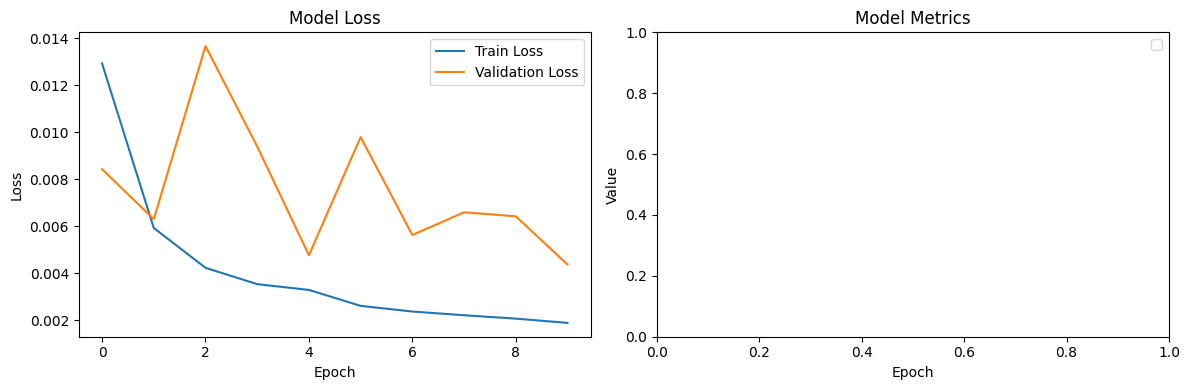

In [11]:
plot_history(trainer.history)

#### Validation Results

In [12]:
trainer.evaluate(val_loader) # run evaluation in case early stop was triggered
trainer.save_model(MODELS_DIR, 'ViTRegressor-tiny.pt')

Evaluation:   0%|          | 0/414 [00:00<?, ?it/s]

Model ViTRegressor-tiny.pt saved to /home/aislab/princisgh_map_completeness/map_completeness_estimation/model_weights


# Test result and metrics

In [15]:
import torch.nn as nn

test_loader = DataLoader(test_ds, batch_size=params['batch_size'], num_workers=8, drop_last=True)
y_hat, y_true, loss = trainer.predict(test_loader)
y_hat, y_true = y_hat.squeeze(), y_true.squeeze()

# map filenames are expected in the format 'id@run@time'
env_id = lambda x: x.split('@')[0]
result_dict = defaultdict(list)
for i in range(len(test_ds)-1):
    mapname = test_ds.df['id'].iloc[i] 
    result_dict[env_id(mapname)].append(abs(y_hat[i] - y_true[i])) # store the absolute prediction error, grouped by map

average_errors = [(id, sum(lst) / len(lst)) for id, lst in result_dict.items()]

Evaluation:   0%|          | 0/376 [00:00<?, ?it/s]

In [16]:
print("Map completeness percentage prediction results")
for env, err in average_errors:
    print(f"{env:>40} -> {float(err)*100:.2f}%")
print(f"\nAverage: {sum([x[1] for x in average_errors]) / len(average_errors)*100:.2f}%")

Map completeness percentage prediction results
                                     8-1 -> 3.90%
                                   E18-1 -> 4.81%
                                   E60-1 -> 3.69%
                      MediaCache_updated -> 2.85%
                          Rustic_updated -> 0.73%
                       Vipiteno2_updated -> 6.39%
                                    W8-1 -> 2.71%
         ZELLENBOROS_GRUPPENZONE_updated -> 5.23%
                       autoSales_updated -> 1.21%
                                   lab_a -> 6.62%
                                   lab_f -> 4.04%
      modern-office-floor-plan-1_updated -> 2.44%
                                office_b -> 3.69%
 scuola_secondaria_i_grado_mera__updated -> 1.94%
         south_mountain_school_1_updated -> 5.50%

Average: 3.72%
